# Classification on Iris Dataset & Polynomial Regression
# Machine Learning Assignment - Mudit(April2025)


# PART 1: Classification Using Iris Dataset

# 🔹 Task 1: Data Loading & Exploration

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.datasets import load_iris

In [91]:
# Load iris dataset from sklearn
iris = load_iris()

In [92]:
# Convert into Pandas DataFrame for better readability
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [93]:
# Add target column
df['target'] = iris.target

In [94]:
# Map numeric target to species names
df['species'] = df['target'].map(dict(zip(range(3), iris.target_names)))

In [95]:
# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [96]:
# Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 6)


In [97]:
# Summary statistics
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [98]:
# Class distribution
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


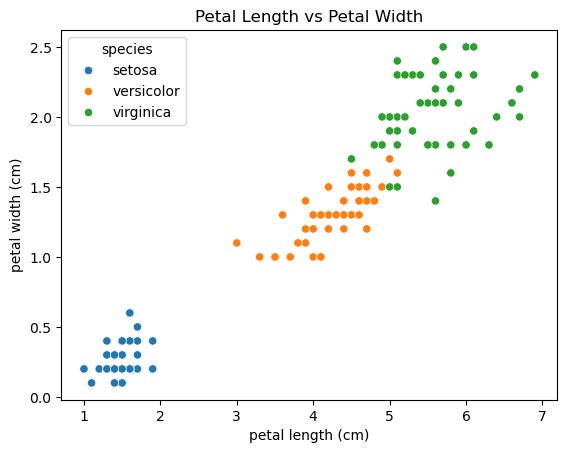

In [99]:
# Scatter plot
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species', data=df)
plt.title("Petal Length vs Petal Width")
plt.show()

# Questions:
1.       How many classes are present in the dataset?
            There are 3 classes:
                Setosa
                Versicolor
                Virginica
2.       Which two features appear most useful for classification?
                Petal length and petal width
                They show clear separation between classes.   

# 🔹 Task 2: Data Preprocessing

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [101]:
X = df.iloc[:, :-2]
y = df['target']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [103]:
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (120, 4)
Testing size: (30, 4)


In [104]:
# Create scaler object
scaler = StandardScaler()
# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data
X_test_scaled = scaler.transform(X_test)

# Questions:

    1. Why is feature scaling important for KNN?
            Because KNN uses distance calculation (Euclidean distance).
            Large-scale features dominate smaller ones without scaling.

    2. Why is scaling less important for Decision Trees?
            Trees split based on feature thresholds — not distance.
            Scaling doesn’t affect splitting logic.

# 🔹 Task 3: Logistic Regression

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [106]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [107]:
y_pred_log = log_model.predict(X_test_scaled)

In [108]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [109]:
coeff_df = pd.DataFrame(
    log_model.coef_,
    columns=X.columns,
    index=iris.target_names
)

coeff_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.003166,1.144873,-1.811348,-1.69251
versicolor,0.527990,-0.283200,-0.340607,-0.72014
virginica,0.475175,-0.861673,2.151955,2.41265


    Positive coefficient → increases probability of that class
    Negative coefficient → decreases probability

# Questions:
1.       Can Logistic Regression handle multi-class problems?
           Yes. It uses:
               One-vs-Rest (OvR)
               Multinomial softmax
2.       Which class was predicted with highest accuracy?
           Usually Setosa has highest accuracy because it's clearly separable.

# 🔹 Task 4: KNN

In [110]:
from sklearn.neighbors import KNeighborsClassifier

In [111]:
k_values = [3,5,7,9]
accuracies = []

In [112]:
for k in k_values:
    # Create model
    knn = KNeighborsClassifier(n_neighbors=k)
    # Train
    knn.fit(X_train_scaled, y_train)
    # Predict
    y_pred = knn.predict(X_test_scaled)
    # Store accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc}")

K = 3, Accuracy = 1.0
K = 5, Accuracy = 1.0
K = 7, Accuracy = 1.0
K = 9, Accuracy = 1.0


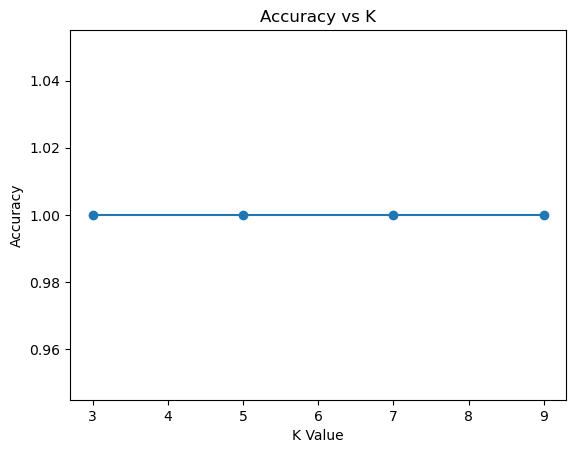

In [113]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

# Questions:
1.       What happens when K is very small?
            Low bias
            High variance
            Overfitting
2.       What happens when K is very large?
            High bias
            Low variance
            Underfitting
3.       Explain bias vs variance in context of K value.
            Small K → Overfit
            Large K → Underfit

# 🔹 Task 5: Decision Tree

In [114]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [115]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

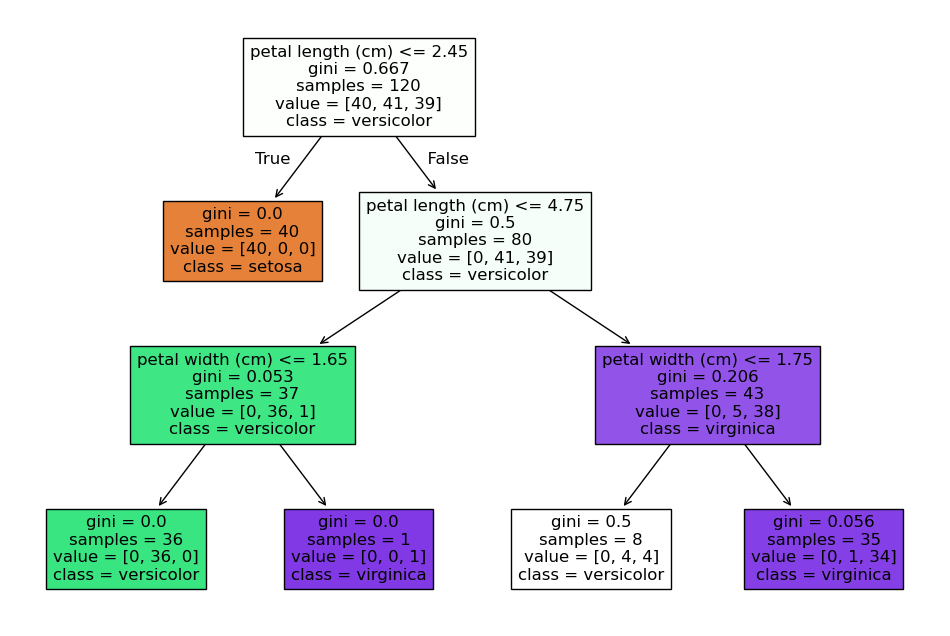

In [116]:
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=X.columns, class_names=iris.target_names, filled=True)
plt.show()

In [117]:
# Try different depths
depths = [1, 2, 3, 5, None]

for depth in depths:
    
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    
    print(f"Depth: {depth}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("-----------")

Depth: 1
Train Accuracy: 0.675
Test Accuracy: 0.6333333333333333
-----------
Depth: 2
Train Accuracy: 0.95
Test Accuracy: 0.9666666666666667
-----------
Depth: 3
Train Accuracy: 0.9583333333333334
Test Accuracy: 1.0
-----------
Depth: 5
Train Accuracy: 0.9916666666666667
Test Accuracy: 1.0
-----------
Depth: None
Train Accuracy: 1.0
Test Accuracy: 1.0
-----------


# Questions:
1.       Does increasing depth lead to overfitting?
            Yes. Deep trees memorize training data.
2.       Why do Decision Trees not require feature scaling?
            Because splits are threshold-based.

# 🔹 Task 6: Model Comparison Table

In [118]:
# Dictionary to store results
model_results = {}
# Logistic Regression
model_results["Logistic Regression"] = accuracy_score(y_test, y_pred_log)

In [119]:
# KNN (use best K — example K=5, change if needed)
best_knn = KNeighborsClassifier(n_neighbors=5)
best_knn.fit(X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)

In [120]:
model_results["KNN (K=5)"] = accuracy_score(y_test, y_pred_knn)

In [121]:
# Decision Tree (use best depth — example max_depth=3)
best_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)

In [122]:
model_results["Decision Tree"] = accuracy_score(y_test, y_pred_tree)

In [123]:
# Convert dictionary to DataFrame
comparison_df = pd.DataFrame(
    model_results.items(),
    columns=["Model", "Accuracy"]
)

In [124]:
# Sort by highest accuracy
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)
comparison_df

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN (K=5),1.0
2,Decision Tree,1.0


In [125]:
comparison_df["Strength"] = [
    "Simple, probabilistic, interpretable",
    "Non-parametric, flexible decision boundary",
    "Highly interpretable, tree structure"
]

comparison_df["Weakness"] = [
    "Assumes linear boundary",
    "Slow for large datasets",
    "Can overfit easily"
]

comparison_df

,Model,Accuracy,Strength,Weakness
0,Logistic Regression,1.0,"Simple, probabilistic, interpretable",Assumes linear boundary
1,KNN (K=5),1.0,"Non-parametric, flexible decision boundary",Slow for large datasets
2,Decision Tree,1.0,"Highly interpretable, tree structure",Can overfit easily


# Model Comparison Analysis

    The best performing models are Logistic Regression, KNN (K=5), and Decision Tree, each achieving an accuracy of 1.00 (100%) on the test dataset.

    Logistic Regression performs well because Iris dataset is nearly linearly separable.

    KNN performance depends heavily on K value.

    Decision Tree is the most interpretable model due to clear rule-based splits.

    Deep trees tend to overfit training data.

In [126]:
print("Decision Tree Train Accuracy:", best_tree.score(X_train, y_train))
print("Decision Tree Test Accuracy:", best_tree.score(X_test, y_test))

Decision Tree Train Accuracy: 0.9583333333333334
Decision Tree Test Accuracy: 1.0


# PART 2: POLYNOMIAL REGRESSION

# 🔹 Task 7: Generate Data

In [127]:
np.random.seed(42)

In [128]:
# Generate 100 random X values
X = np.random.rand(100, 1)
# Add Gaussian noise
noise = np.random.randn(100, 1)
# True relationship
y = 4 + 3*(X**2) + noise

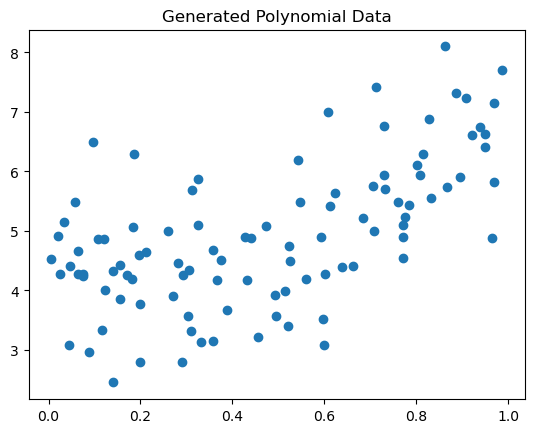

In [129]:
plt.scatter(X, y)
plt.title("Generated Polynomial Data")
plt.show()

# Questions:
1.       Is this relationship linear or non-linear?
            Non-linear (quadratic).
2.       Why was noise added?
            To simulate real-world randomness.

# 🔹 Task 8: Linear Regression

In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [131]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [132]:
y_pred = lin_reg.predict(X)
print("MSE:", mean_squared_error(y, y_pred))

MSE: 0.9314215989204719


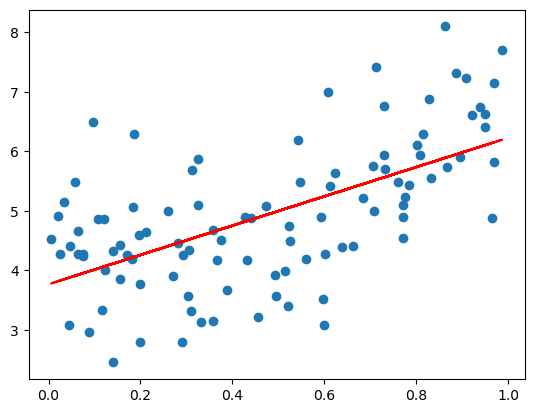

In [133]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.show()

# Questions:
1.       Why does Linear Regression fail on this dataset?
            Because relationship is quadratic.
2.       Is this underfitting or overfitting?
            Underfitting.

# 🔹 Task 9: Polynomial Regression

In [134]:
from sklearn.preprocessing import PolynomialFeatures

In [135]:
degrees = [2, 3, 10]

In [136]:
for degree in degrees:
    
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    
    mse = mean_squared_error(y, y_pred)
    
    print(f"Degree {degree} → MSE: {mse}")

Degree 2 → MSE: 0.7771936663502369
Degree 3 → MSE: 0.7724650788837722
Degree 10 → MSE: 0.7399087981921043


# Questions:
1.       Which degree fits best?
            Degree 2 (since true function is quadratic).
2.       What happens when degree is very high?
            Overfitting.
3.       Explain bias-variance tradeoff using this example.
            Degree 1 → High bias, low variance
            Degree 2 → Balanced
            Degree 10 → Low bias, high variance